<img src="https://hilpisch.com/tpq_logo_bic.png" width="20%" align="right">

# Python & AI in Asset Management
## Chapter 7 · Data Engineering and Cleaning for Financial Time Series

&copy; Dr. Yves J. Hilpisch<br>
AI-Powered by GPT 5.1<br>
The Python Quants GmbH | https://tpq.io<br>
https://hilpisch.com | https://linktr.ee/dyjh


## Notebook Goals
Chapter 7 emphasizes robust data pipelines. Here we:
- inspect raw data quality,
- repair gaps and flag outliers,
- engineer reusable features, and
- persist cleaned panels for later notebooks.


### Getting Help While Engineering Data
- **Chapter 3** covers pandas fundamentals.
- **Appendix B** summarizes the rolling/resampling APIs used below.
- **Appendix F** contains practical tooling tips for organizing outputs.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("seaborn-v0_8")
plt.rcParams.update({"font.family": "serif", "figure.dpi": 300})

DATA_PATH = Path("../data/pyaiam_eod.csv")
if not DATA_PATH.exists():
    DATA_PATH = "https://hilpisch.com/pyaiam_eod.csv"


## 1. Load Raw Prices and Profile Quality
We begin by checking for missing values and basic summary stats.

In [3]:
prices = pd.read_csv(DATA_PATH, parse_dates=["Date"]).set_index("Date").sort_index()
prices.head()

,AAPL,NVDA,JPM,SPY,GLD,TLT,EURUSD,BTC-USD
Date,,,,,,,,
2015-11-30,26.6730,0.7738,50.8773,176.3432,101.92,93.0004,1.0632,377.321014
2015-12-01,26.4565,0.7989,51.5869,178.0247,102.28,94.2563,1.0613,362.488007
2015-12-02,26.2175,0.7928,50.8620,176.2071,100.69,94.2869,1.0938,359.187012
2015-12-03,25.9740,0.7911,50.2058,173.7406,101.76,91.7239,1.0876,361.045990
2015-12-04,26.8376,0.8233,51.8005,177.1290,104.02,92.5297,NaN,363.183014


In [4]:
# 1. prices.isna()：
# 对整个 DataFrame，每个元素判断「是不是缺失值（NaN）」
# 返回一个和 prices 一模一样形状的布尔矩阵；
# 2. .mean()：对布尔矩阵按列求平均值，在 Python 里：True=1，False=0，所以 .mean() 就等于「True 的个数 / 总数」。

summary = pd.DataFrame({
    "min": prices.min(),
    "max": prices.max(),
    "pct_missing": prices.isna().mean(),
})
summary

,min,max,pct_missing
AAPL,20.604100,278.850000,0.000000
NVDA,0.615200,207.040000,0.000000
JPM,40.764400,320.410000,0.000000
SPY,155.436400,687.390000,0.000000
GLD,100.500000,403.150000,0.000000
TLT,75.932700,147.017000,0.000000
EURUSD,0.959600,1.250500,0.124056
BTC-USD,359.187012,124752.528352,0.000000


### 1.1 Gap Repair and Diagnostics
We forward-fill missing FX values and record which tickers required intervention.

In [6]:
filled = prices.ffill()
# .eq(1)：等于判断：是不是 = 1，只保留第一次缺失的位置。
# .any()：每一列只要有一个 True，就返回 True。
fill_flags = prices.isna().cumsum().eq(1).any()
fill_flags

,0
AAPL,False
NVDA,False
JPM,False
SPY,False
GLD,False
TLT,False
EURUSD,True
BTC-USD,False


## 2. Outlier Detection
A rolling z-score flags extreme moves for manual review.

In [7]:
log_rets = np.log(filled / filled.shift(1)).dropna()
zscores = (log_rets - log_rets.rolling(63).mean()) / log_rets.rolling(63).std()
outlier_mask = zscores.abs() > 4                                  # mask住
outlier_counts = outlier_mask.sum().sort_values(ascending=False)
outlier_counts

,0
SPY,14
BTC-USD,14
JPM,11
AAPL,10
NVDA,9
GLD,6
EURUSD,5
TLT,4


### 2.1 Visualizing Flagged Points
We overlay outlier markers on a sample series.

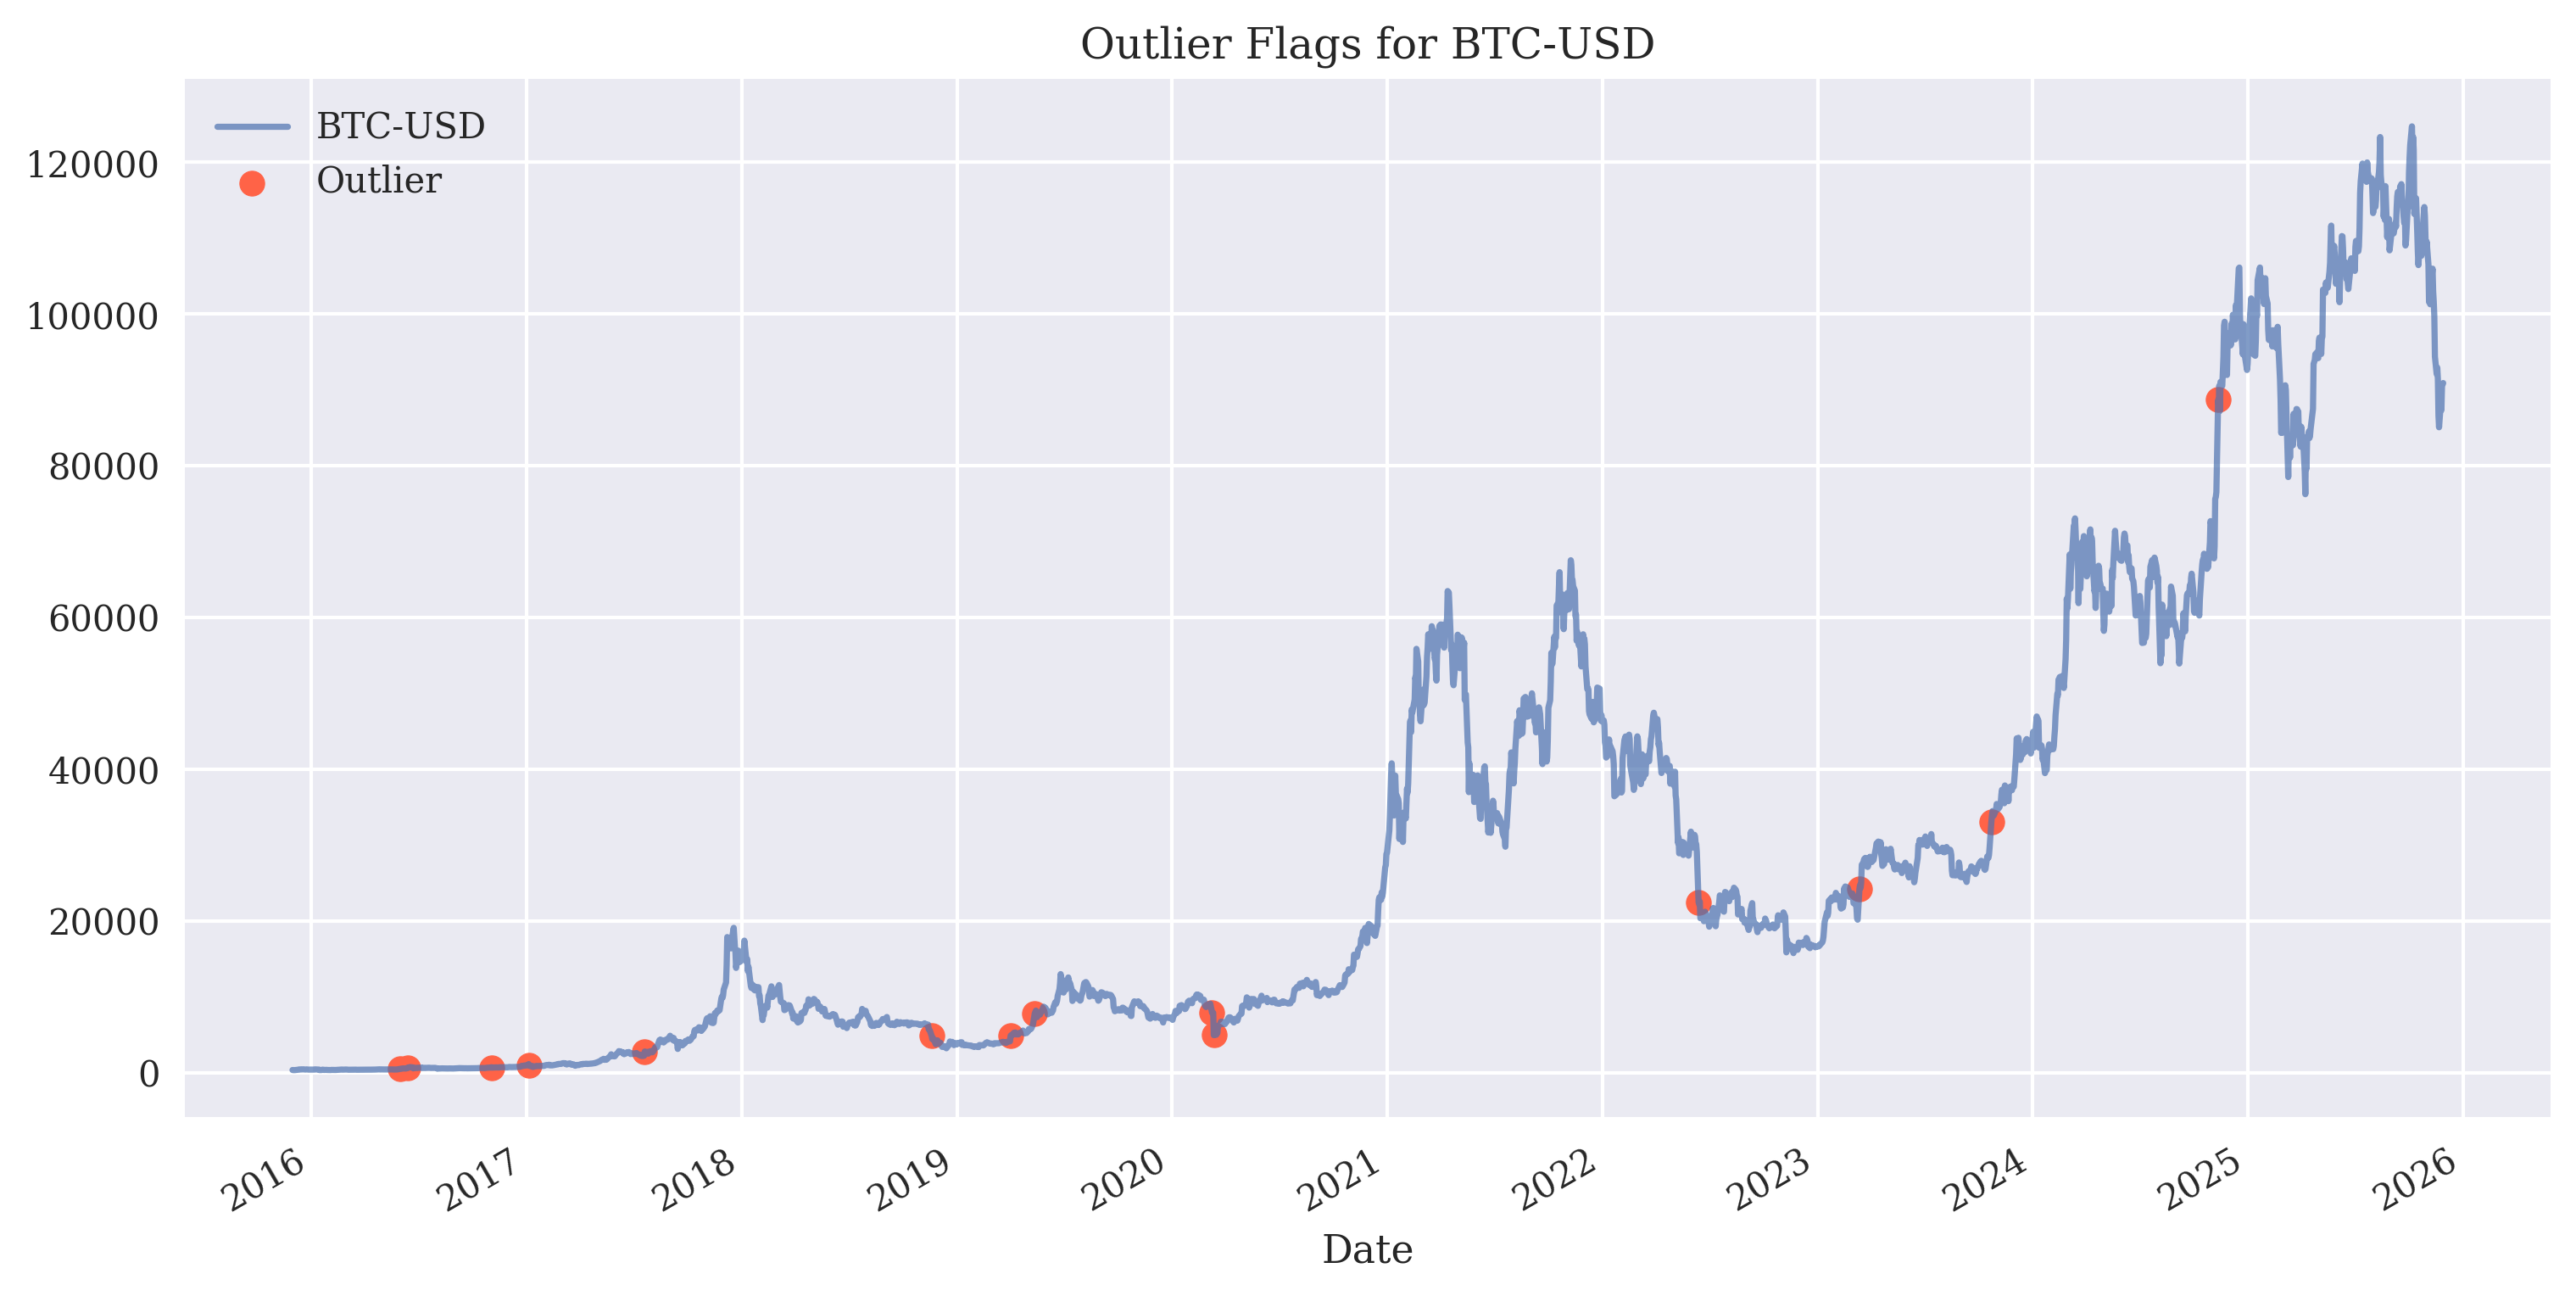

In [24]:
ticker = "BTC-USD"
fig, ax = plt.subplots(figsize=(12, 6))
filled[ticker].plot(ax=ax, alpha=0.7)
mask = outlier_mask[ticker].reindex(filled.index, fill_value=False)
ax.scatter(
    filled.index[mask],
    filled[ticker][mask],
    color="tomato",
    label="Outlier",
)
ax.set_title(f"Outlier Flags for {ticker}")
ax.legend()
plt.show()

## 3. Feature Engineering Helper
We compute rolling volatility, momentum, and z-scores for downstream models.

In [28]:
def build_features(price_frame: pd.DataFrame, window: int = 21) -> pd.DataFrame:
    log_ret = np.log(price_frame / price_frame.shift(1))
    vol = log_ret.rolling(window).std() * np.sqrt(252)
    momentum = price_frame.pct_change(window)
    rolling_mean = price_frame.rolling(window).mean()
    rolling_std = price_frame.rolling(window).std()
    zscore = (price_frame - rolling_mean) / rolling_std
    out = pd.concat(
        {
            "vol": vol,
            "momentum": momentum,
            "zscore": zscore,
        },
        axis=1,
    )
    return out.dropna()

feature_panel = build_features(filled)
print(feature_panel.head().round(4))

               vol                                                          \
              AAPL    NVDA     JPM     SPY     GLD     TLT  EURUSD BTC-USD   
Date                                                                         
2015-12-30  0.2429  0.2665  0.2693  0.1835  0.1746  0.1647  0.1338  0.6309   
2015-12-31  0.2480  0.2487  0.2658  0.1828  0.1741  0.1581  0.1334  0.6084   
2016-01-04  0.2484  0.2554  0.2815  0.1856  0.1716  0.1604  0.0900  0.6052   
2016-01-05  0.2582  0.2613  0.2788  0.1801  0.1682  0.1277  0.0891  0.6064   
2016-01-06  0.2219  0.2609  0.2558  0.1690  0.1578  0.1323  0.1019  0.6086   

           momentum          ...                  zscore                  \
               AAPL    NVDA  ...  EURUSD BTC-USD    AAPL    NVDA     JPM   
Date                         ...                                           
2015-12-30  -0.0928  0.0526  ...  0.0223  0.1307 -1.0603  1.0288  0.4146   
2015-12-31  -0.1029  0.0064  ...  0.0241  0.1878 -1.3754 -0.0130 -0.048

### 3.1 Persist Clean Panels
Saving intermediate artifacts speeds up later notebooks.

In [29]:
OUTPUT_DIR = Path("../data/features")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
path = OUTPUT_DIR / "pyaiam_features.parquet"   # path = 文件保存路径 + 文件名。
feature_panel.to_parquet(path)                  # to_parquet = 把 DataFrame 高速、压缩、完整地保存到文件。
path

PosixPath('../data/features/pyaiam_features.parquet')

## 4. Data Quality Report Helper
Summaries like the one below fit nicely into Confluence or PDF appendices.

In [ ]:
def data_quality_report(raw: pd.DataFrame, cleaned: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame(
        {
            "pct_missing_before": raw.isna().mean(),
            "pct_missing_after": cleaned.isna().mean(),
            "up_to_date": cleaned.iloc[-1].notna(),        # 检查最新交易日，哪些资产没有数据（缺失）。
        }
    )

dqr = data_quality_report(prices, filled)
dqr

## 5. Exercises
### Exercise 1 – Dynamic Thresholds
Modify the outlier detector to use a MAD-based threshold instead of z-scores.
<details><summary>Hint</summary>
Compute median absolute deviation via <code>rolling(window).apply</code>.
</details>

### Exercise 2 – Sector Aggregation
Assume a mapping from tickers to asset classes (reuse Chapter 1). Aggregate feature means by class each week.
<details><summary>Hint</summary>
Add a column with the mapping, then combine <code>groupby</code> with <code>resample</code>.
</details>

### Exercise 3 – File Versioning
Write a helper that appends a timestamped suffix to every feature file you save.
<details><summary>Hint</summary>
Use <code>datetime.now().strftime("%Y%m%d")</code> and create a new Path per run.
</details>


## 6. Takeaways for Chapter 7
- Basic QC checks catch missing data and outliers early.
- Encapsulating feature logic in functions makes reuse trivial.
- Persisting cleaned panels bridges the gap between research and production workflows.


<img src="https://hilpisch.com/tpq_logo_bic.png" width="20%" align="right">